<a href="https://colab.research.google.com/github/SentineNet-AI-SpringBoard/SentinelNet-AI/blob/AI-sentineNet-Rohan/%20milestone_2SentinelNet_Ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SentinelNet - AI-Powered Network Intrusion Detection System (NIDS)


**MILESTONE - 1**


Week 1: Project Initialization and Dataset Acquisition


Project Goal:

 Develop an AI-powered Network Intrusion Detection System (NIDS) to identify malicious network traffic and cyberattacks in real time using machine learning.

## Project Overview: SentinelNet

SentinelNet is like a smart security guard for computer networks. Its main job is to find and stop bad stuff happening on the network, like hacking attempts or viruses trying to get in.

It uses Artificial Intelligence (AI) to do this, specifically two types of AI:

1.  **Supervised Learning**: This is like teaching the AI by showing it examples of what good network traffic looks like and what bad network traffic (like attacks) looks like. The AI learns the patterns to spot the bad stuff on its own later.
2.  **Unsupervised Learning**: This is like letting the AI explore the network traffic on its own to find unusual patterns or things that don't fit in. This helps it find new or unknown types of attacks that it hasn't been specifically taught to look for.

So, SentinelNet uses these AI techniques to act as a Network Intrusion Detection System (NIDS), constantly watching the network to keep it safe by identifying and alerting about malicious activity.

### Step 2: Dataset Acquisition and Loading

The dataset used in this project is CICIDS2017, obtained from the official source of the Canadian Institute for Cybersecurity.
Dataset: https://www.unb.ca/cic/datasets/ids-2017.html

In [ ]:
# ==========================================================
# 1. Dataset exploration
# ==========================================================
import pandas as pd
import numpy as np
file_path = '/content/drive/MyDrive/Wednesday-workingHours.pcap_ISCX.csv'
df = pd.read_csv(file_path)
## how many rows and columns are in our data. It's like saying how many entries and how many pieces of information there are for each entry.
print(f"Dataset shape: {df.shape}")
##prints the text "First 5 rows:" to the output.
print("\nFirst 5 rows:")
## (.head())is function  used to on a dataframe it gives few rowss of dataframe.
print(df.head())
## this line used to show what kind of infomation is in each column
## how many entries are complete. It helps you quickly understand the data types and if there are any missing values.
print("\nData Types Check and Basic Info Summary:")
df.info()
## it for columns that cantain number in your data
##  It shows things like the average, how spread out the numbers are, and the smallest and largest values.
print("\nBasic Statistics for Numerical Columns:")
print(df.describe())
## this line can show you that how many missing values are are in each column of in the data.
print("\nCount of Missing Values per Column:")
print(df.isnull().sum())

Dataset shape: (692703, 79)

First 5 rows:
    Destination Port   Flow Duration   Total Fwd Packets  \
0                 80           38308                   1   
1                389             479                  11   
2                 88            1095                  10   
3                389           15206                  17   
4                 88            1092                   9   

    Total Backward Packets  Total Length of Fwd Packets  \
0                        1                            6   
1                        5                          172   
2                        6                         3150   
3                       12                         3452   
4                        6                         3150   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                             6                       6   
1                           326                      79   
2                          3150                    1575   
3    

In [ ]:
display(df.head())

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
# ==========================================================
# 2. Handle Duplicates and Irrelevant Features
# ==========================================================
# Assuming 'df' from previous steps is available and cleaned
# If not, load the original data first as cleaning happens here
file_path = '/content/drive/MyDrive/Wednesday-workingHours.pcap_ISCX.csv'
df = pd.read_csv(file_path)

df.columns = df.columns.str.strip()
initial_rows, initial_cols = df.shape

# Handle Duplicates (Rows)
df.drop_duplicates(inplace=True)

# Handle Irrelevant Features (Columns)
irrelevant_cols = ['Flow ID', 'Timestamp']
df.drop(columns=[col for col in irrelevant_cols if col in df.columns], inplace=True)

final_rows, final_cols = df.shape
print(f"\n--- Data Cleaning Summary ---")
### this helps you that how many rows and columns your data had before cleaning
print(f"Initial Shape: {initial_rows} rows, {initial_cols} columns")
###print(f"Rows removed (Duplicates): {initial_rows - final_rows}")
print(f"Final Shape:   {final_rows} rows, {final_cols} columns")
### This line shows you how many duplicate rows were removed from your data.
print(f"Rows removed (Duplicates): {initial_rows - final_rows}")
###This line shows you how many columns were removed because they were not relevant.
print(f"Columns removed (Irrelevant Features): {initial_cols - final_cols}")


--- Data Cleaning Summary ---
Initial Shape: 692703 rows, 79 columns
Final Shape:   610794 rows, 79 columns
Rows removed (Duplicates): 81909
Columns removed (Irrelevant Features): 0


In [ ]:
# ==========================================================
# 3. Save Cleaned Data (Intermediate)
# ==========================================================
# Save the cleaned data to the content directory
df.to_csv('cleaned_data_intermediate.csv', index=False)
print("\nIntermediate cleaned data saved to: cleaned_data_intermediate.csv")


Intermediate cleaned data saved to: cleaned_data_intermediate.csv


In [ ]:
# ==========================================================
# 4. Identify Categorical and Numerical Features
# ==========================================================
try:
    df
except NameError:
    file_path = '/content/drive/MyDrive/Wednesday-workingHours.pcap_ISCX.csv'
    df = pd.read_csv(file_path)

### this lines help  which columns have text and which have numbers in your data.
categorical_features = df.select_dtypes(include='object').columns.tolist()
numerical_features = df.select_dtypes(include=np.number).columns.tolist()
### These lines simply show you the lists of columns that were identified as having text (categorical) and those with numbers.
print(f"\nCategorical Features: {categorical_features}")
print(f"Numerical Features: {numerical_features}")


Categorical Features: ['Label']
Numerical Features: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count'


Correlation Matrix (Top 5 features):
                             Destination Port  Flow Duration  \
Destination Port                     1.000000      -0.236650   
Flow Duration                       -0.236650       1.000000   
Total Fwd Packets                   -0.003992       0.014201   
Total Backward Packets              -0.003765       0.013226   
Total Length of Fwd Packets          0.011162       0.076978   

                             Total Fwd Packets  Total Backward Packets  \
Destination Port                     -0.003992               -0.003765   
Flow Duration                         0.014201                0.013226   
Total Fwd Packets                     1.000000                0.998900   
Total Backward Packets                0.998900                1.000000   
Total Length of Fwd Packets           0.726478                0.725832   

                             Total Length of Fwd Packets  \
Destination Port                                0.011162   
Flow Duratio

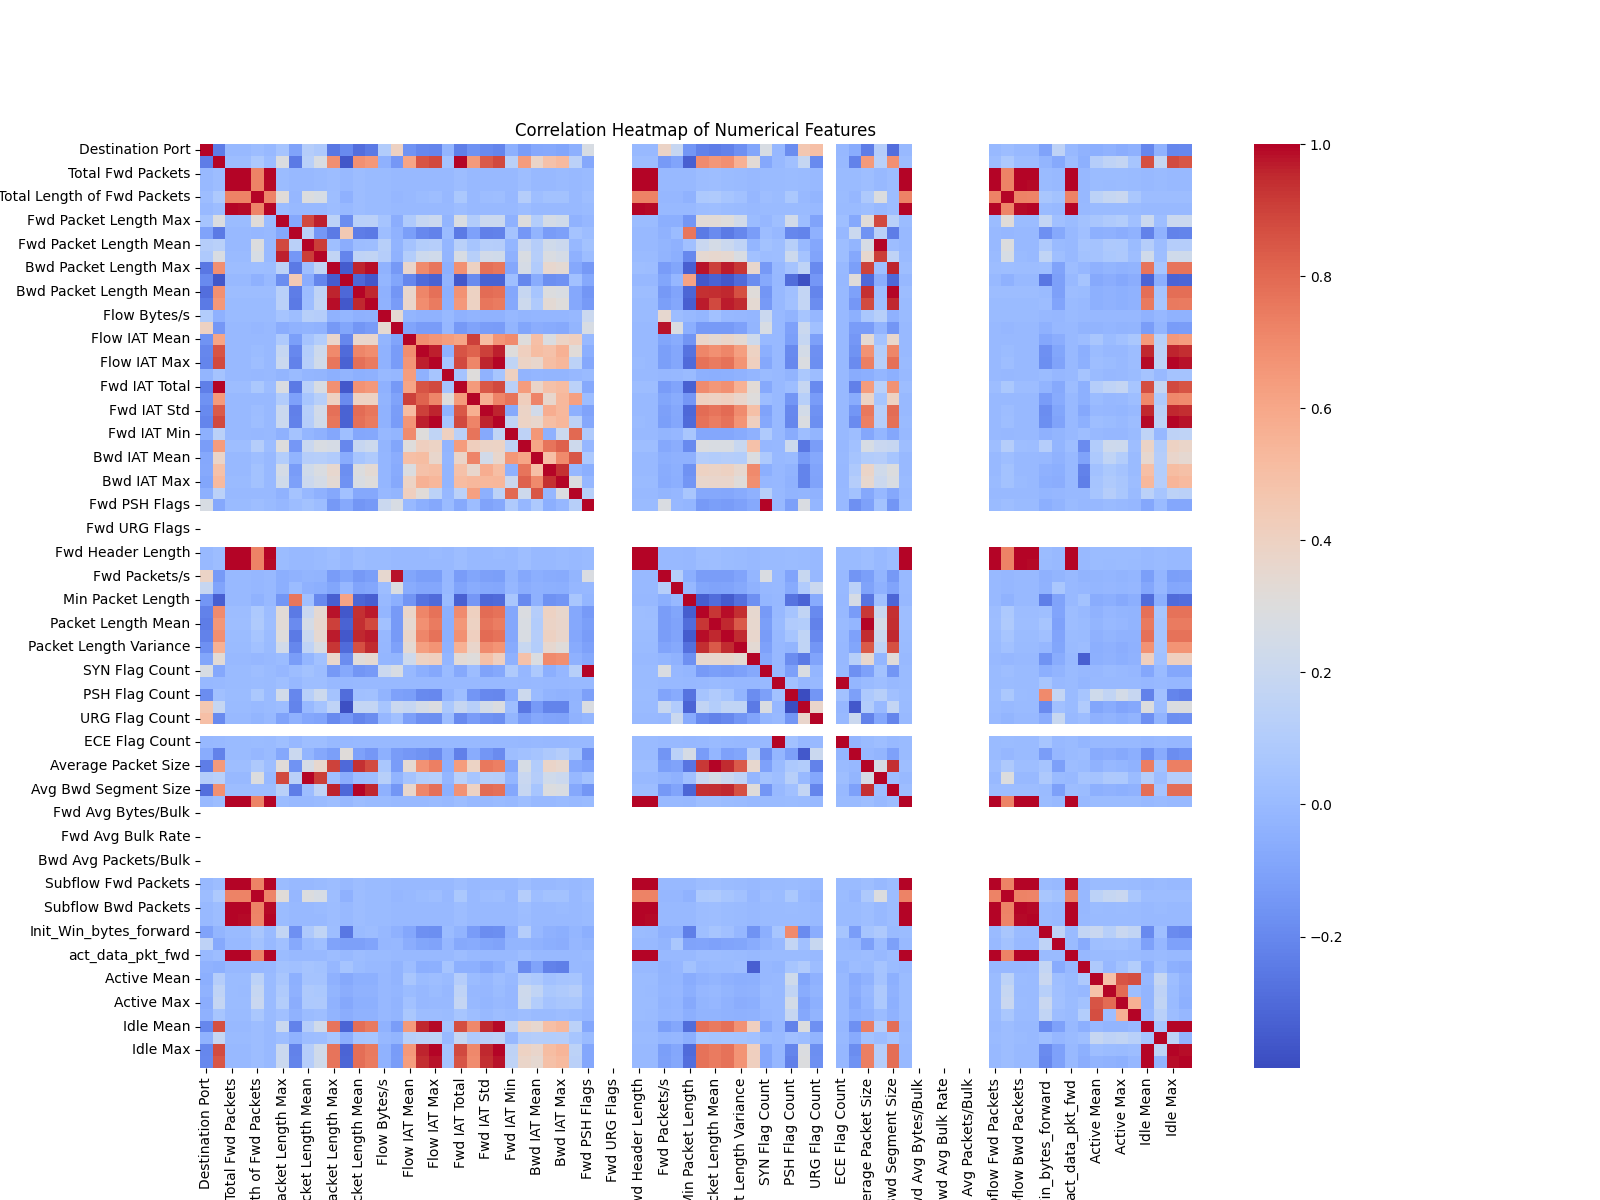

<Figure size 1600x1200 with 0 Axes>

In [ ]:
# ==========================================================
# 5. Check correlation using heatmap
# ==========================================================
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display
# Assuming 'df' from previous steps is available and cleaned
# If not, load the original data or cleaned intermediate data
try:
    df
except NameError:
    file_path = '/content/drive/MyDrive/Wednesday-workingHours.pcap_ISCX.csv'
    df = pd.read_csv(file_path)

###These lines calculate how much each number column in your data is related to every other number column
correlation_matrix = df[numerical_features].corr()
print("\nCorrelation Matrix (Top 5 features):")
print(correlation_matrix.head())
##This line creates a colored map to show how strongly the number columns are related to each other.
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
## This line adds a title to the correlation heatmap so you know what the plot is showing.
plt.title('Correlation Heatmap of Numerical Features')
plt.savefig('correlation_heatmap.png')
plt.clf()
print("\nCorrelation heatmap saved as: correlation_heatmap.png")

# Display the saved correlation heatmap image
display(Image('correlation_heatmap.png'))


Number of outliers in 'Bwd Packet Length Max' (IQR method): 23199

Boxplot saved as: boxplot_outliers.png


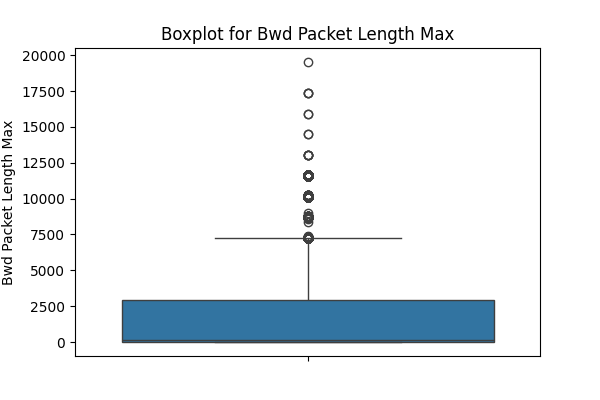

<Figure size 600x400 with 0 Axes>

In [ ]:
# ==========================================================
# 6. Check for outliers with and without boxplot
# ==========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

file_path = '/content/drive/MyDrive/Wednesday-workingHours.pcap_ISCX.csv'
df = pd.read_csv(file_path)
### These lines find the values that divide your data into quarters.
outlier_col = 'Bwd Packet Length Max'
if outlier_col in df.columns:
  ### is the value where 25% of the data is below it,
    Q1 = df[outlier_col].quantile(0.25)
    ### is where 75% of the data is below it.
    Q3 = df[outlier_col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    ###  outliers_iqr = df[(df[outlier_col] < lower_bound) | (df[outlier_col] > upper_bound)]
    outliers_iqr = df[(df[outlier_col] < lower_bound) | (df[outlier_col] > upper_bound)]
    print(f"\nNumber of outliers in '{outlier_col}' (IQR method): {len(outliers_iqr)}")
    ### These lines create a boxplot to visually show the distribution of data and highlight potential outliers, then save the plot as an image file.
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df[outlier_col])
    plt.title(f'Boxplot for {outlier_col}')
    plt.savefig('boxplot_outliers.png')
    plt.clf()
    print(f"\nBoxplot saved as: boxplot_outliers.png")

    # Display the saved boxplot image
    display(Image('boxplot_outliers.png'))
else:
    print(f"\nColumn '{outlier_col}' not found for outlier check.")

In [ ]:
# ==========================================================
# 7. Check for important and non important features
# ==========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

file_path = '/content/drive/MyDrive/Wednesday-workingHours.pcap_ISCX.csv'
df = pd.read_csv(file_path)
## These lines help you find which columns have numbers and which have text in your data.
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
### This line shows you the numerical columns with the fewest different values, which might be less important.
categorical_features = df.select_dtypes(include=['object', 'category']).columns

print("\nUnique count for numerical features (low count may suggest low importance):")
print(df[numerical_features].nunique().sort_values().head(10))
### If there are any text columns, these lines show you all the unique values in each of those columns and how many times each value appears.
if len(categorical_features) > 0:
    print("\nValue counts for categorical features:")
    for col in categorical_features:
        print(f"{col}:\n{df[col].value_counts()}\n")


Unique count for numerical features (low count may suggest low importance):
 Bwd PSH Flags           1
 Fwd Avg Bulk Rate       1
Bwd Avg Bulk Rate        1
 Bwd Avg Packets/Bulk    1
 Bwd Avg Bytes/Bulk      1
Fwd Avg Bytes/Bulk       1
 Bwd URG Flags           1
 Fwd Avg Packets/Bulk    1
 CWE Flag Count          1
 Fwd URG Flags           1
dtype: int64

Value counts for categorical features:
 Label:
 Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64



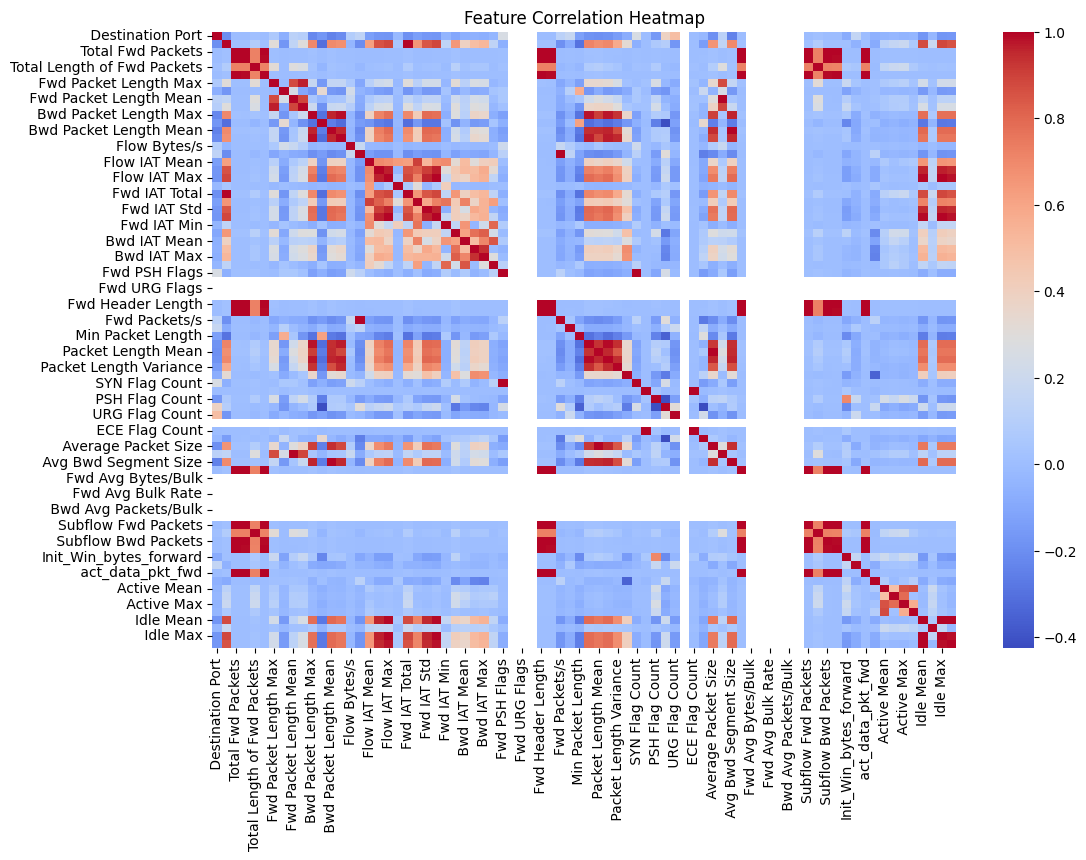

In [ ]:
# Analyzing correlations between numeric features to identify strongly related attributes
# Correlation shows how strongly two features are related — high correlation means they change together and vice-versa.

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Load the data
file_path = '/content/drive/MyDrive/Wednesday-workingHours.pcap_ISCX.csv'
df = pd.read_csv(file_path)

plt.figure(figsize=(12,8))

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

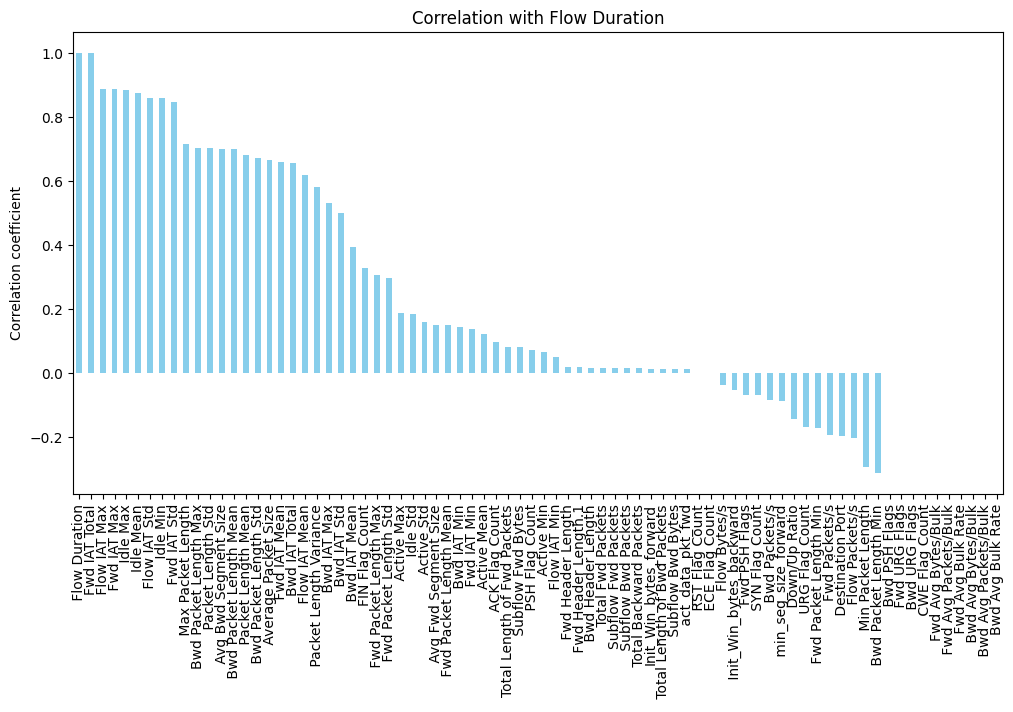

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Load the original data
file_path = '/content/drive/MyDrive/Wednesday-workingHours.pcap_ISCX.csv'
df = pd.read_csv(file_path)

# Plotting the correlation using bargraph
numeric_df = df.select_dtypes(include=['int64', 'float64'])
target_corr = numeric_df.corr()[' Flow Duration'].sort_values(ascending=False)

plt.figure(figsize=(12,6))
target_corr.plot(kind='bar', color='skyblue')
plt.title("Correlation with Flow Duration")
plt.ylabel("Correlation coefficient")
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# Load the original data - assuming the path is correct
file_path = '/content/drive/MyDrive/Wednesday-workingHours.pcap_ISCX.csv'
df = pd.read_csv(file_path)

# Separating dataset columns into categorical and numerical features
categorical_features = df.select_dtypes(include=['object']).columns
numerical_features = df.select_dtypes(include=['int64','float64']).columns

print("Categorical:", categorical_features)
print("Numerical:", numerical_features)

Categorical: Index([' Label'], dtype='object')
Numerical: Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',

Correlation with target:
  Flow Duration           1.000000
Fwd IAT Total            0.999268
 Flow IAT Max            0.886932
 Fwd IAT Max             0.886773
 Idle Max                0.884918
                           ...   
 Fwd Avg Packets/Bulk         NaN
 Fwd Avg Bulk Rate            NaN
 Bwd Avg Bytes/Bulk           NaN
 Bwd Avg Packets/Bulk         NaN
Bwd Avg Bulk Rate             NaN
Name:  Flow Duration, Length: 78, dtype: float64


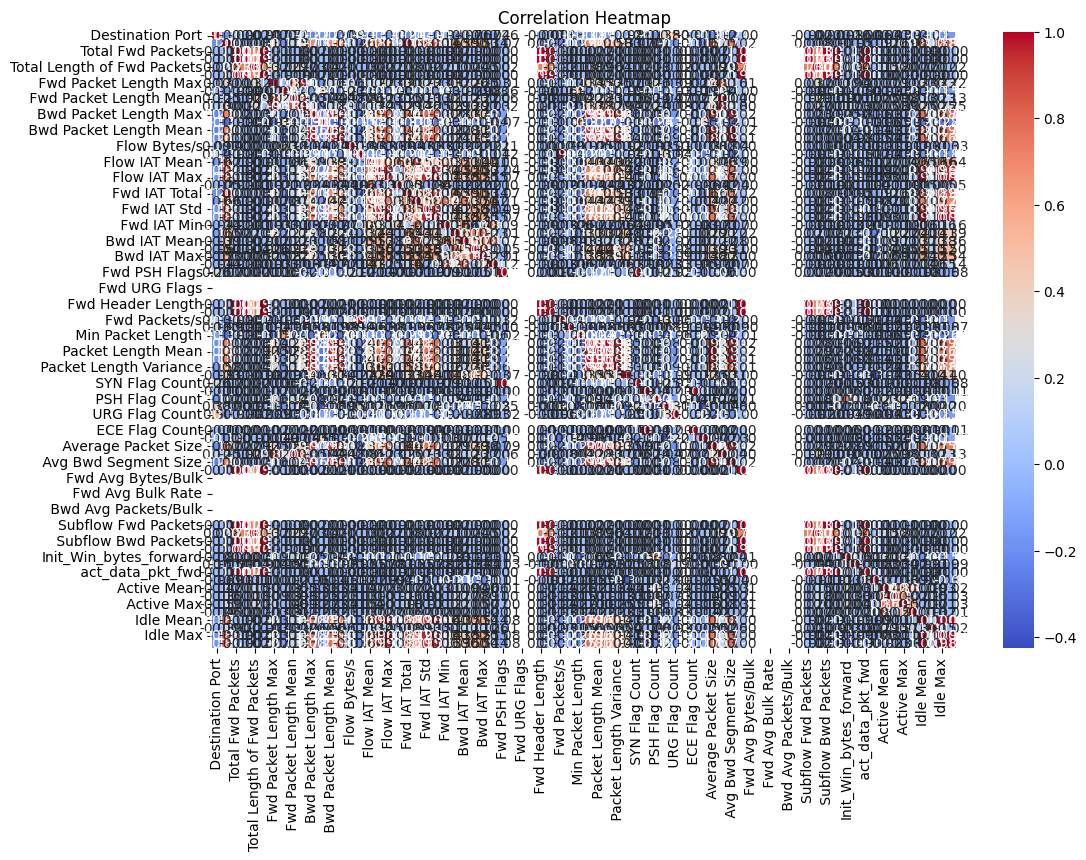

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Load the data if not already loaded (assuming df is available from previous steps)
try:
    df
except NameError:
    file_path = '/content/drive/MyDrive/Wednesday-workingHours.pcap_ISCX.csv'
    df = pd.read_csv(file_path)

# Select only numeric columns before calculating correlation
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation with target
target_corr = numeric_df.corr()[' Flow Duration'].sort_values(ascending=False)  # replace 'target_column'

print("Correlation with target:\n", target_corr)

# Heatmap of all numerical features
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Evaluating model...
Evaluation completed in 0.00 seconds.

--- Model Evaluation Metrics ---
Accuracy: 0.9023

Classification Report:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                  precision    recall  f1-score   support

          BENIGN       0.90      0.98      0.94    124857
   DoS GoldenEye       0.00      0.00      0.00      3148
        DoS Hulk       0.90      0.83      0.86     51959
DoS Slowhttptest       0.00      0.00      0.00      1552
   DoS slowloris       0.00      0.00      0.00      1631
      Heartbleed       0.00      0.00      0.00         1

        accuracy                           0.90    183148
       macro avg       0.30      0.30      0.30    183148
    weighted avg       0.87      0.90      0.89    183148


Confusion Matrix:


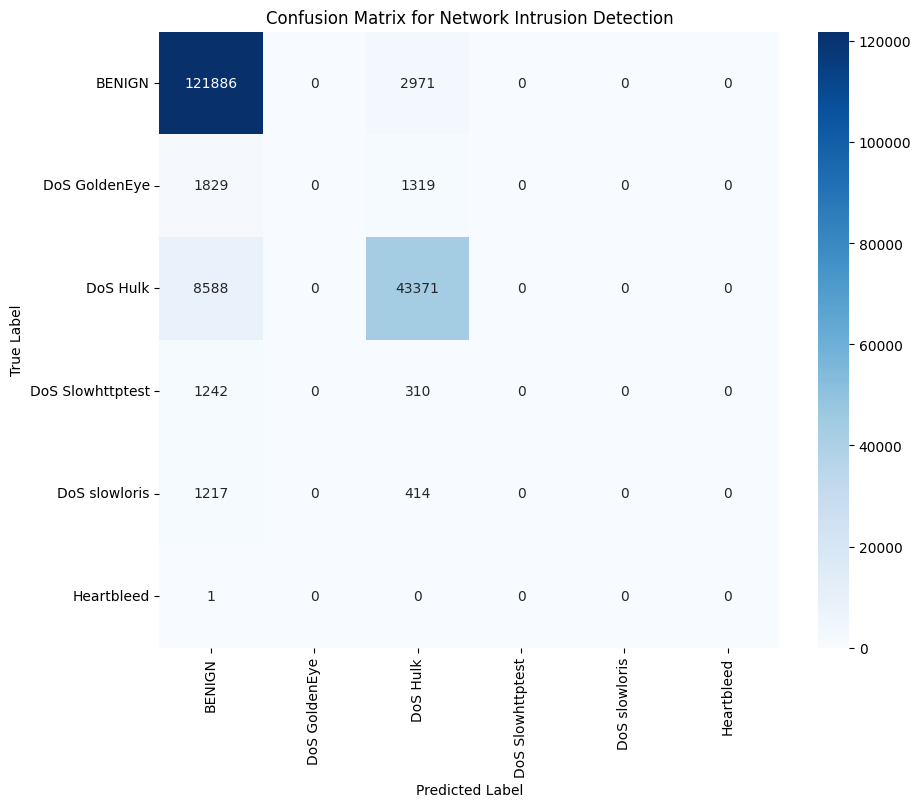

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Load the original data
file_path = '/content/drive/MyDrive/Wednesday-workingHours.pcap_ISCX.csv'
df = pd.read_csv(file_path)

# Handle Duplicates and Irrelevant Features
df.columns = df.columns.str.strip()
irrelevant_cols = ['Flow ID', 'Timestamp'] # Assuming these were identified as irrelevant
df.drop(columns=[col for col in irrelevant_cols if col in df.columns], inplace=True)
df.drop_duplicates(inplace=True)

# Drop columns with infinite values
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# Separate features (X) and target (y)
X = df.drop('Label', axis=1)
y = df['Label']

# Identify numerical features (excluding the target)
numerical_features = X.select_dtypes(include=np.number).columns.tolist()

# Standardize the numerical data
scaler = StandardScaler()
X[numerical_features] = scaler.fit_transform(X[numerical_features])

# Apply PCA (using the appropriate number of components, here just an example)
pca = PCA(n_components=2) # Adjust n_components as needed
X_pca = pca.fit_transform(X[numerical_features]) # Apply PCA to numerical features

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)

# Train a Logistic Regression model (or any other model you intend to use)
model = LogisticRegression(max_iter=1000) # Increased max_iter for potential convergence issues
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model (as in the previous code cell)
print("Evaluating model...")
start_time = time.time()

end_time = time.time()
evaluation_time = end_time - start_time

print(f"Evaluation completed in {evaluation_time:.2f} seconds.")

# Display evaluation metrics
print("\n--- Model Evaluation Metrics ---")

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Classification Report (includes Precision, Recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)

# Plotting the Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Network Intrusion Detection')
plt.show()

Step - 3 : Normalize or standardize numerical features.

In [ ]:
import numpy as np
import pandas as pd

# Load the data if not already loaded
try:
    df
except NameError:
    file_path = '/content/drive/MyDrive/Wednesday-workingHours.pcap_ISCX.csv'
    df = pd.read_csv(file_path)

# Identify numerical features
numerical_features = df.select_dtypes(include=np.number).columns.tolist()

# Replace inf/-inf with NaN
df[numerical_features] = df[numerical_features].replace([np.inf, -np.inf], np.nan)

# Optionally drop rows with NaN
df[numerical_features] = df[numerical_features].dropna()

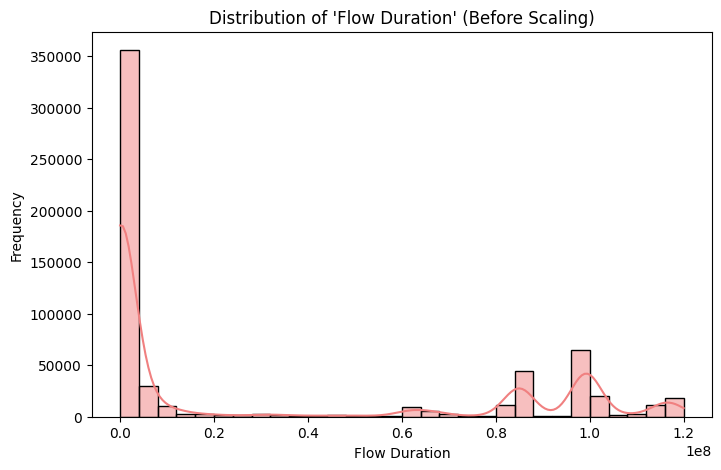

In [ ]:
# Example: Visualize 'Flow Duration' before scaling
plt.figure(figsize=(8,5))
sns.histplot(df['Flow Duration'], bins=30, kde=True, color='lightcoral')
plt.title("Distribution of 'Flow Duration' (Before Scaling)")
plt.xlabel("Flow Duration")
plt.ylabel("Frequency")
plt.show()

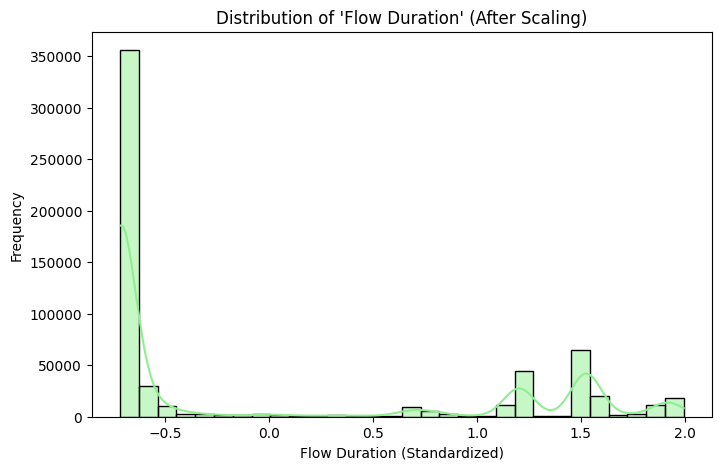

In [ ]:
from sklearn.preprocessing import StandardScaler

# Standardize the numerical feature
scaler = StandardScaler()
df['Flow Duration_scaled'] = scaler.fit_transform(df[['Flow Duration']])

# Plot the scaled feature
plt.figure(figsize=(8,5))
sns.histplot(df['Flow Duration_scaled'], bins=30, kde=True, color='lightgreen')
plt.title("Distribution of 'Flow Duration' (After Scaling)")
plt.xlabel("Flow Duration (Standardized)")
plt.ylabel("Frequency")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
df.columns = df.columns.str.strip()

X = df.drop('Label', axis=1)  # Features
y = df['Label']               # Target variable

# Split data: 80% training, 20% testing, with reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (488393, 79)
Testing set size: (122099, 79)


In [ ]:
from sklearn.model_selection import train_test_split
df.columns = df.columns.str.strip()

X = df.drop('Label', axis=1)  # Features
y = df['Label']               # Target variable

# Split data: 80% training, 20% testing, with reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (488393, 79)
Testing set size: (122099, 79)


**milestone**-**2**

Week 3: Feature Engineering and Selection

In [ ]:
print("Dataset shape:", df.shape)
print("Unique labels:", df['Label'].unique())

Dataset shape: (610492, 80)
Unique labels: ['BENIGN' 'DoS slowloris' 'DoS Slowhttptest' 'DoS Hulk' 'DoS GoldenEye'
 'Heartbleed']


In [ ]:
# Saving the preprocessed and encoded dataset to a new CSV file 'Wednesday_Encoded.csv'
df.to_csv("Wednesday_Encoded.csv", index=False)

Step - 1 : Correlation Analysis for Dimensionality Reduction

In [ ]:
# 1. Select only numeric columns for the correlation calculation
# And ensure 'Label' is handled numerically for correlation analysis.
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Ensure df is loaded (if not already) and column names are stripped of whitespace
try:
    df
except NameError:
    file_path = '/content/drive/MyDrive/Wednesday-workingHours.pcap_ISCX.csv'
    df = pd.read_csv(file_path)

df.columns = df.columns.str.strip()

# Encode the target variable 'Label' if it's not already numeric
if 'Label' in df.columns:
    if df['Label'].dtype == 'object':
        le = LabelEncoder()
        df['Label_encoded'] = le.fit_transform(df['Label'])
        target_column = 'Label_encoded'
    elif 'Label_encoded' in df.columns:
        target_column = 'Label_encoded' # Already encoded from previous cell
    else:
        target_column = 'Label' # Assume 'Label' is already numeric if not object
else:
    print("Error: 'Label' column not found in DataFrame. Cannot perform target correlation.")
    target_column = None # No target column to correlate with

# Select numerical features for correlation, ensuring the encoded target is included
numeric_df_for_corr = df.select_dtypes(include=['int64', 'float64']).copy()

# Add 'Label_encoded' to numeric_df_for_corr if it was created and not already there
if target_column == 'Label_encoded' and target_column not in numeric_df_for_corr.columns:
    numeric_df_for_corr[target_column] = df[target_column]

if target_column:
    # 4. Compute the correlation matrix
    corr_matrix = numeric_df_for_corr.corr()

    # 5. Get the absolute correlation of all features with the target column
    target_corr = corr_matrix.abs()[target_column].sort_values(ascending=False)

    # Exclude the target column itself from the important/non-important features list
    target_corr = target_corr.drop(labels=[target_column], errors='ignore')

    # 6. Identify important features (correlation > 0.3)
    important_features = target_corr[target_corr > 0.3].index.tolist()

    # 7. Identify non-important features (correlation <= 0.3)
    non_important_features = target_corr[target_corr <= 0.3].index.tolist()

    # --- Print the lists of features ---
    print("Important Features (correlation with '" + target_column + "' > 0.3):", important_features)
    print("Non-Important Features (correlation with '" + target_column + "' <= 0.3):", non_important_features)

    # 8. Create a new DataFrame with only the important features and the original 'Label' for context
    # Ensure original 'Label' column is added back for later use (e.g., splitting, training)
    df_filtered = df[important_features + ['Label']].copy()

    # --- Print the final shape of the filtered DataFrame ---
    print("Shape after dropping non-important features:", df_filtered.shape)

else:
    print("Cannot perform feature selection based on correlation with 'Label' as it was not found or encoded.")

Important Features (correlation with 'Label_encoded' > 0.3): ['Idle Max', 'Fwd IAT Max', 'Flow IAT Max', 'Fwd IAT Std', 'Idle Mean', 'Idle Min', 'Bwd Packet Length Mean', 'Avg Bwd Segment Size', 'Flow IAT Std', 'Bwd Packet Length Std', 'Bwd Packet Length Max', 'Packet Length Std', 'Max Packet Length', 'Packet Length Mean', 'Average Packet Size', 'Packet Length Variance', 'Fwd IAT Total', 'Flow Duration', 'Fwd IAT Mean', 'Bwd Packet Length Min', 'Flow IAT Mean', 'Min Packet Length', 'ACK Flag Count', 'FIN Flag Count']
Non-Important Features (correlation with 'Label_encoded' <= 0.3): ['Bwd IAT Std', 'Bwd IAT Max', 'Destination Port', 'Down/Up Ratio', 'URG Flag Count', 'Bwd IAT Mean', 'min_seg_size_forward', 'Fwd Packets/s', 'Fwd Packet Length Min', 'Flow Packets/s', 'Bwd IAT Total', 'PSH Flag Count', 'Idle Std', 'Init_Win_bytes_backward', 'Active Mean', 'Init_Win_bytes_forward', 'Fwd PSH Flags', 'SYN Flag Count', 'Active Min', 'Bwd Packets/s', 'Active Max', 'Avg Fwd Segment Size', 'Fwd P

Step - 2 : PCA Analysis

In [ ]:
# --- Separate the data into features (X) and the target (y) ---

# X contains all the important feature columns (the inputs for the model).
# We use .drop() to remove the 'Label' column because it's what we want to predict.
X = df_filtered.drop(columns=['Label'])

# y contains only the target column (the output the model will learn to predict).
y = df_filtered['Label']

# --- Print the shapes to verify the separation ---
print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (692703, 24)
Target (y) shape: (692703,)


In [ ]:
from sklearn.impute import SimpleImputer

# Fill missing values with median (robust for numeric data)
imputer = SimpleImputer(strategy='median')

X_imputed = imputer.fit_transform(X)
X_imputed = pd.DataFrame(X_imputed, columns=X.columns)

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Verify no NaNs remain
print("Number of NaNs after scaling:", np.isnan(X_scaled).sum())

Number of NaNs after scaling: 0


In [ ]:
from sklearn.decomposition import PCA

# Fit PCA on scaled data
pca = PCA() ## all components for full analysis
X_pca = pca.fit_transform(X_scaled)

In [ ]:
print("Shape before PCA:", X_scaled.shape)
print("Shape after PCA:", X_pca.shape)

Shape before PCA: (692703, 24)
Shape after PCA: (692703, 24)


In [ ]:
explained_variance = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(pca.explained_variance_))],
    'Explained_Variance': pca.explained_variance_ratio_
}).sort_values(by='Explained_Variance', ascending=False)



In [ ]:
# Display top 10 PCA components
top_10_pca = explained_variance.head(10)
print("Top 10 PCA Components based on explained variance:")
print(top_10_pca)

Top 10 PCA Components based on explained variance:
     PC  Explained_Variance
0   PC1            0.678993
1   PC2            0.100233
2   PC3            0.073841
3   PC4            0.043907
4   PC5            0.028685
5   PC6            0.022891
6   PC7            0.016112
7   PC8            0.011182
8   PC9            0.008515
9  PC10            0.005450


Step - 3 : Analyze Feature Importance

In [ ]:
from sklearn.model_selection import train_test_split
# Split dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestClassifier
# Initialize Random Forest with 50 trees as suggested
rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)

# Train the model
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [ ]:
X.columns

Index(['Idle Max', 'Fwd IAT Max', 'Flow IAT Max', 'Fwd IAT Std', 'Idle Mean',
       'Idle Min', 'Bwd Packet Length Mean', 'Avg Bwd Segment Size',
       'Flow IAT Std', 'Bwd Packet Length Std', 'Bwd Packet Length Max',
       'Packet Length Std', 'Max Packet Length', 'Packet Length Mean',
       'Average Packet Size', 'Packet Length Variance', 'Fwd IAT Total',
       'Flow Duration', 'Fwd IAT Mean', 'Bwd Packet Length Min',
       'Flow IAT Mean', 'Min Packet Length', 'ACK Flag Count',
       'FIN Flag Count'],
      dtype='object')

In [ ]:
# Extract feature importance
importances = rf.feature_importances_

# Create a DataFrame to visualize importance
# Use rf_trained_features_columns for consistency if available, otherwise X.columns
if 'rf_trained_features_columns' in globals():
    feature_names = rf_trained_features_columns
else:
    feature_names = X.columns # Fallback, assumes X is consistent with rf

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display top 10 most important features
top_10_features = feature_importance_df.head(10)
print("Top 10 Features contributing to attacks:")
print(top_10_features)


Top 10 Features contributing to attacks:
                   Feature  Importance
9    Bwd Packet Length Std    0.125295
7     Avg Bwd Segment Size    0.086366
6   Bwd Packet Length Mean    0.083286
15  Packet Length Variance    0.076601
11       Packet Length Std    0.073996
14     Average Packet Size    0.069836
10   Bwd Packet Length Max    0.065847
12       Max Packet Length    0.056054
13      Packet Length Mean    0.049772
1              Fwd IAT Max    0.038838


Top 10 Features contributing to attacks:
                   Feature  Importance
5     Avg Bwd Segment Size    0.196610
11   Bwd Packet Length Std    0.165722
4   Bwd Packet Length Mean    0.079829
9        Packet Length Std    0.065911
13       Max Packet Length    0.061998
15  Packet Length Variance    0.061728
14     Average Packet Size    0.043309
8    Bwd Packet Length Max    0.037305
3              Fwd IAT Std    0.036299
0              Fwd IAT Max    0.028384


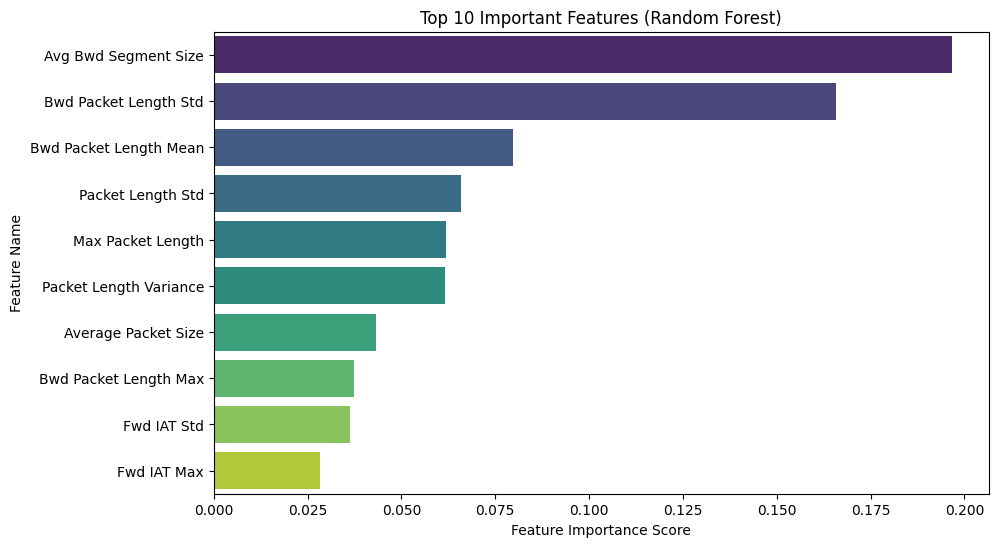

In [ ]:
# Visualize top 10 most important features
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming 'rf' (trained Random Forest model) and 'X' (features DataFrame) are available
# Extract feature importance
try:
    importances = rf.feature_importances_

    # Create a DataFrame to visualize importance
    feature_importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    # Display top 10 most important features
    top_10_features = feature_importance_df.head(10)
    print("Top 10 Features contributing to attacks:")
    print(top_10_features)

    # Visualize top 10 most important features
    plt.figure(figsize=(10,6))
    sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis')
    plt.title("Top 10 Important Features (Random Forest)")
    plt.xlabel("Feature Importance Score")
    plt.ylabel("Feature Name")
    plt.show()

except NameError:
    print("Error: 'rf' or 'X' not found. Please ensure the model training and feature selection steps have been run.")

In [ ]:
# Select top 10 features
top_features = top_10_features['Feature'].tolist()

# Include the label column
selected_columns = top_features + ['Label']

# Create a new DataFrame with selected columns
top_features_df = df_filtered[selected_columns]

# Save to CSV file
top_features_df.to_csv("top10_features_dataset.csv", index=False)

print("Top 10 feature dataset saved as 'top10_features_dataset.csv'")

Top 10 feature dataset saved as 'top10_features_dataset.csv'


Week - 4 : Supervised Model Training

In [ ]:
import pandas as pd
# Load the saved dataset containing top 10 important features and the label
df = pd.read_csv("top10_features_dataset.csv")

In [ ]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Label_encoded
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0


In [ ]:
print("Shape:", df.shape)

Shape: (610492, 11)


In [ ]:
# Separate independent variables (features) and dependent variable (label)
X = df.drop(columns=['Label'])
y = df[['Label']]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (692703, 79)
Target vector shape: (692703, 1)


In [ ]:
from sklearn.model_selection import train_test_split
# Split dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (554162, 24)
Testing data shape: (138541, 24)


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

(i) Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
# Initialize and train Random Forest classifier
rf = RandomForestClassifier(
    n_estimators=50,     # fewer trees
    max_depth=8,         # limit tree depth
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=8, min_samples_leaf=5, min_samples_split=10,
                       n_estimators=50, random_state=42)